# PyTorch Fundamentals

            ## 1. Learning objectives

            - Create tensors and datasets
- Use modules, losses, optimizers, and DataLoader
- Inspect gradients and parameters

            ## 2. Prerequisites

            NumPy arrays, matrix multiplication, basic derivatives, and the supervised-learning workflow.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(1)
device = torch.device("cpu")
print("PyTorch:", torch.__version__, "| device:", device)

Python lesson ready; reproducible seed = 42
PyTorch: 2.14.0+cpu | device: cpu


## 3. Problem definition

            Express a reproducible training loop with automatic differentiation and mini-batches.

            ## 4. Real-world use cases

            - Image recognition
- Sequence modeling
- Learned feature representations

            ## 5. Core intuition in simple language

            A DataLoader supplies batches; the module predicts; loss measures error; backward computes gradients; the optimizer changes parameters.

## 6. Mathematical foundation

            $$\mathbf{h}=\phi(\mathbf{X}\mathbf{W}+\mathbf{b}).$$

            **Every symbol:**

            - $\mathbf{X}$ is a batch of inputs.
- $\mathbf{W}$ is a learned weight matrix.
- $\mathbf{b}$ is a learned bias vector.
- $\phi$ is an activation function.
- $\mathbf{h}$ is the resulting representation.

            **Why the equation is needed:** Without the activation, stacked linear layers collapse to one linear transformation; the activation enables nonlinear patterns.

            **Small numerical example:** For x=[1,2], w=[.5,-.25], and b=.1, z=1(.5)+2(-.25)+.1=.1; ReLU(z)=.1.

            **Connection to Python:** torch.relu(X @ W + b) implements the equation while autograd records the operations.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Create tensors with explicit batch and feature dimensions
2. Run a forward pass
3. Compute a loss against targets
4. Backpropagate gradients
5. Update parameters with an optimizer
6. Evaluate on untouched validation data

## 9. Implementation from scratch

NumPy exposes the forward calculation and, where appropriate, the gradients.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
X_np = rng.normal(size=(80, 2))
true_w = np.array([[2.0], [-1.0]])
y_np = X_np @ true_w + .5
w_np = np.zeros((2, 1)); b_np = 0.0
for _ in range(120):
    prediction = X_np @ w_np + b_np
    error = prediction - y_np
    w_np -= .05 * (2/len(X_np)) * X_np.T @ error
    b_np -= .05 * 2 * error.mean()
print("NumPy weights/bias:", w_np.ravel().round(3), round(float(b_np), 3))

NumPy weights/bias: [ 1.998 -0.998] 0.5


## 10. Implementation using a standard library

PyTorch tensors, modules, autograd, losses, and optimizers provide the standard implementation.

## 11. Dataset loading and exploration

Every lesson uses a generated sequence or a small dataset bundled with scikit-learn; no download is required.

## 12. Data preprocessing

Splits occur before fitted transformations. Inputs are converted to float32 tensors and class labels to int64.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Model diagnostics: {'input_shape': (60, 2), 'intermediate_shape': 'not applicable (single affine layer)', 'output_shape': (60, 1), 'trainable_parameters': 3, 'final_training_loss': 0.0, 'final_validation_loss': 1e-06, 'validation_RMSE': 0.000711}
Learned: [[ 2.    -0.999]] [0.5]


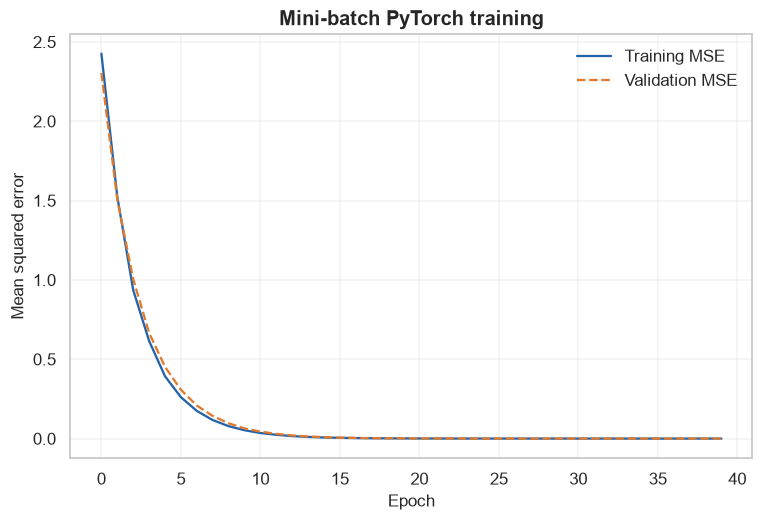

In [3]:
X = torch.tensor(X_np[:60], dtype=torch.float32)
y = torch.tensor(y_np[:60], dtype=torch.float32)
validation_X = torch.tensor(X_np[60:], dtype=torch.float32)
validation_y = torch.tensor(y_np[60:], dtype=torch.float32)
loader = DataLoader(TensorDataset(X, y), batch_size=16, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=.05)
loss_fn = nn.MSELoss()
history = []; validation_history = []
for epoch in range(40):
    model.train()
    total = 0.0
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        prediction = model(batch_X)
        loss = loss_fn(prediction, batch_y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(batch_X)
    history.append(total / len(X))
    model.eval()
    with torch.no_grad():
        validation_prediction = model(validation_X)
        validation_loss = loss_fn(validation_prediction, validation_y)
    validation_history.append(validation_loss.item())
validation_rmse = float(torch.sqrt(loss_fn(validation_prediction, validation_y)))
print("Model diagnostics:", {
    "input_shape": tuple(X.shape),
    "intermediate_shape": "not applicable (single affine layer)",
    "output_shape": tuple(model(X).shape),
    "trainable_parameters": sum(p.numel() for p in model.parameters()),
    "final_training_loss": round(history[-1], 6),
    "final_validation_loss": round(validation_history[-1], 6),
    "validation_RMSE": round(validation_rmse, 6),
})
print("Learned:", model.weight.detach().numpy().round(3), model.bias.detach().numpy().round(3))
figure, axis = plt.subplots()
axis.plot(history, color=COURSE_COLORS["blue"], label="Training MSE")
axis.plot(validation_history, color=COURSE_COLORS["orange"], linestyle="--", label="Validation MSE")
axis.set(title="Mini-batch PyTorch training", xlabel="Epoch", ylabel="Mean squared error")
axis.legend()
plt.show()

**How to interpret the result:** PyTorch recovers the known linear weights while recording each operation needed for gradients.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Batch size trades noisy frequent updates against stable less-frequent updates and memory use.

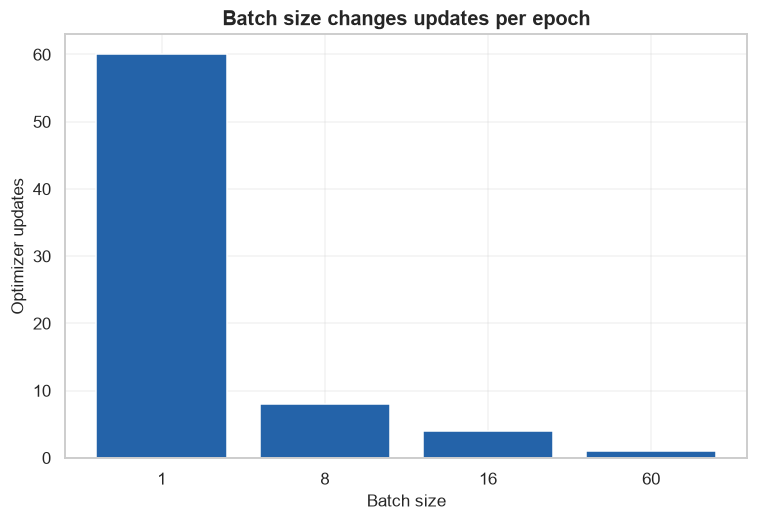

In [4]:
batch_sizes = [1, 8, 16, len(X)]
updates_per_epoch = [int(np.ceil(len(X)/size)) for size in batch_sizes]
figure, axis = plt.subplots()
axis.bar([str(value) for value in batch_sizes], updates_per_epoch, color=COURSE_COLORS["blue"])
axis.set(title="Batch size changes updates per epoch", xlabel="Batch size", ylabel="Optimizer updates")
plt.show()

## 18. Common mistakes

            - Forgetting batch and feature dimensions
- Applying softmax before CrossEntropyLoss
- Evaluating on the training set
- Leaving gradients accumulated between optimizer steps

            ## 19. Advantages and disadvantages

            **Advantages**

            - Learns features jointly with predictions
- Flexible building blocks for structured data

            **Disadvantages**

            - Needs careful optimization and validation
- Can be computationally expensive and difficult to interpret

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the data and task benefit from learned nonlinear representations and validation supports the added complexity.

            **Do not use it when:** a small tabular dataset is handled well by a simpler, easier-to-audit model.

## 21. Exercises

1. **Conceptual:** Why do hidden layers need nonlinear activations?
2. **Mathematical/hand calculation:** Calculate ReLU([−2, 0, 3]).
3. **Coding/experimentation:** Double hidden width and compare parameter count and validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Without nonlinearities, multiple affine layers equal one affine layer.
2. The result is [0, 0, 3].
3. Change the layer width, count parameters, retrain with the same split, and compare training-versus-validation loss rather than training loss alone.

</details>

## 23. Summary and key takeaways

            - Tensor shapes are part of the model specification
- Forward propagation produces predictions and backpropagation produces gradients
- Training and validation curves reveal optimization and generalization

            ## 24. Further reading

            - [PyTorch tutorials](https://pytorch.org/tutorials/)
- [PyTorch neural-network modules](https://pytorch.org/docs/stable/nn.html)